***Machine Learning Assignment***
# Predicitng Kenyan Financial Situations
**Done by Junaid, Clyde, Vinit, and Lee**
The basis of this project is to use data from 20,871 Kenyan adults surveyed in 2024 to build a machine learning model that can predict whether a person's financial situation has improved, stayed the same, or worsened, as well as identifying the key factors that drive the financial outcomes in Kenya.

## Table of Contents
- [Project Phases](#project-phases)
- [Data Acquisition](#data-acquisition)
- [Data Preprocessing](#data-preprocessing)
    - [Encoding the Data](#encoding-the-data)
- [Feature Selection](#feature-selection)
- [Model Validation and Testing](#model-validation-and-testing)
- [Data visualization](#data-visualization)

## Project Phases
The project is broken down into the following phases:
1. Data acquisition: the dataset is sourced from Kaggle [https://www.kaggle.com/datasets/davidpbriggs/kenya-finaccess-household-survey-2024](https://www.kaggle.com/datasets/davidpbriggs/kenya-finaccess-household-survey-2024)
2. Data cleaning and preprocessing: missing values are handled, and non-numeric features are encoded for use in models
3. Feature selection: specific features are selected to use during training, primarily through Lasso (L1) regression
4. Model selection and testing: a model (either SVM, ANN, or decision trees) is chosen to use, and it is tested with the data
5. Data visualization: the results of the data and any findings are visualized for presentation

## Data Acquisition
As mentioned before, the data has been pulled from Kaggle: [https://www.kaggle.com/datasets/davidpbriggs/kenya-finaccess-household-survey-2024](https://www.kaggle.com/datasets/davidpbriggs/kenya-finaccess-household-survey-2024). A copy of the dataset it saved within the repository as well.

## Data Preprocessing
This is the first stage of the project. We import the dataset and get a summary of the columns and data we're dealing with.  
From there, we handle any missing values and encode the data for usage in models.

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_excel('finaccess2024_datasprint.xlsx')

print(df.shape)

df.head()

(20871, 28)


,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,...,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability
0,Garissa,Urban,Female,26-35,5,Completed technical training after secondary s...,Married/Living with partner,30000,Non-usage,Non-usage,...,Yes,Yes,Yes,Yes,No,Stayed the same,All correct,3,NaN,Without Disability
1,Garissa,Urban,Female,Above 55,11,"""None """,Married/Living with partner,10000,Non-usage,Non-usage,...,No,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability
2,Busia,Urban,Female,26-35,2,"""Primary completed""",Divorced/separated,3000,Usage,Usage,...,Yes,No,No,No,No,Improved,All correct,5,Affordability,Without Disability
3,Kiambu,Urban,Male,18-25,1,"""Some secondary""",Single/Never Married,10000,Usage,Non-usage,...,No,No,No,Yes,No,Improved,All correct,4,Affordability,Without Disability
4,Murang'a,Urban,Female,18-25,1,Some technical training after secondary school,Single/Never Married,10000,Usage,Non-usage,...,Yes,Yes,Yes,Yes,Yes,Improved,All correct,5,NaN,Without Disability


In [2]:
# Locate any columns with missing data
df.isna().sum()

county                      0
location_type               0
Sex                         0
Age                         0
household_size              0
education_level             0
marital_status              0
monthly_income              0
Savings_formal              0
Savings_informal            0
Loan_formal                 0
Loan_informal               0
defaulted                   0
formal_service_use          0
mobile_money_access         0
barriers_mobile_money       0
mobile_ownership_1          0
experienced_shock           0
nfhi_11                     0
nfhi_12                     0
nfhi_13                     0
accessto_13k_1month         0
not_difficult               0
financial_status            0
fl_score                    0
prodsum1                    0
barriers_bank            5734
has_disability              0
dtype: int64

From the above, we can see only one column has missing values: `barriers_bank`.  
`barriers_bank` indicates what barriers a person might have when accessing a bank, such as not being able to afford it, being illegible, difficult access, and so on. We can substitute the missing values with the text `No Barriers` as that makes the most sense.


In [3]:
df.fillna(value={"barriers_bank": "No barrier"}, inplace=True)

print(f"NaN values present in full dataset: {df.isna().sum().sum()}")

df.head()

NaN values present in full dataset: 0


,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,...,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability
0,Garissa,Urban,Female,26-35,5,Completed technical training after secondary s...,Married/Living with partner,30000,Non-usage,Non-usage,...,Yes,Yes,Yes,Yes,No,Stayed the same,All correct,3,No barrier,Without Disability
1,Garissa,Urban,Female,Above 55,11,"""None """,Married/Living with partner,10000,Non-usage,Non-usage,...,No,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability
2,Busia,Urban,Female,26-35,2,"""Primary completed""",Divorced/separated,3000,Usage,Usage,...,Yes,No,No,No,No,Improved,All correct,5,Affordability,Without Disability
3,Kiambu,Urban,Male,18-25,1,"""Some secondary""",Single/Never Married,10000,Usage,Non-usage,...,No,No,No,Yes,No,Improved,All correct,4,Affordability,Without Disability
4,Murang'a,Urban,Female,18-25,1,Some technical training after secondary school,Single/Never Married,10000,Usage,Non-usage,...,Yes,Yes,Yes,Yes,Yes,Improved,All correct,5,No barrier,Without Disability


Let's also look out for any mixed data types in the columns.

In [4]:
# Find mixed data types
for column in df.columns:
    col_type = pd.api.types.infer_dtype(df[column])
    if "mixed" in col_type:
        print(f"{column}: {col_type}")

df[['education_level', 'barriers_mobile_money']].head()

education_level: mixed-integer
barriers_mobile_money: mixed-integer


,education_level,barriers_mobile_money
0,Completed technical training after secondary s...,0
1,"""None """,0
2,"""Primary completed""",0
3,"""Some secondary""",0
4,Some technical training after secondary school,0


From the above, we can see that the `education_level` and `barriers_mobile_money` have mixed data types, most likely integers mixed in with the string values.

For the `education_level`, we can remove any columns with an integer in them, as that's probably an outlier. For `barriers_mobile_money`, we can convert all cells with a `0` to `No barriers`, similar to the `bank_barriers` column.

In [5]:
# Handle the education_level column
education_col = df['education_level']
num = pd.to_numeric(education_col, errors='coerce')
is_int = num.notna() & (num % 1 == 0)
df = df.loc[~is_int]

# Handle the barriers_mobile_money column
df.loc[df['barriers_mobile_money'] == 0, 'barriers_mobile_money'] = 'No barrier'

print(df.shape)

df[['education_level', 'barriers_mobile_money']].head()

(20869, 28)


,education_level,barriers_mobile_money
0,Completed technical training after secondary s...,No barrier
1,"""None """,No barrier
2,"""Primary completed""",No barrier
3,"""Some secondary""",No barrier
4,Some technical training after secondary school,No barrier


The marital status columns also has two values we need to remove from the dataset:
- Don't know   (DO NOT READ OUT)
- Refused to Answer(DO NOT READ OUT)

Some people also didn't answer what education level they're in, so we should remove that as well.

In [6]:
invalid_rows = df[
    (df['marital_status'].isin(["Don't know   (DO NOT READ OUT)", "Refused to Answer(DO NOT READ OUT)"])) 
    | (df['education_level'] == "\"Refused to Answer (DO NOT READ OUT)\"")
    ].index
df.drop(invalid_rows, inplace=True)

print(df.shape)

# Get the number of unique values in each column
df.nunique()

(20857, 28)


county                    47
location_type              2
Sex                        2
Age                        6
household_size            20
education_level           11
marital_status             4
monthly_income           236
Savings_formal             2
Savings_informal           2
Loan_formal                2
Loan_informal              2
defaulted                  2
formal_service_use         2
mobile_money_access        2
barriers_mobile_money     10
mobile_ownership_1         2
experienced_shock          2
nfhi_11                    2
nfhi_12                    2
nfhi_13                    2
accessto_13k_1month        2
not_difficult              2
financial_status           3
fl_score                   4
prodsum1                  23
barriers_bank             10
has_disability             2
dtype: int64

### Encoding the Data
We can now setup a column transformer using Scikit-Learn to handle encoding the data and preprocessing it.

For all columns which have two or more unique values (excluding the county, prodsum1, and fl_score), we'll use one-hot encoding.

Counties will be encoded using a target encoder. FL_score will use label encoding, as well as financial situation.

In [7]:
one_hot_cols = [
    'location_type',
    'Sex',
    'Age',
    'education_level',
    'marital_status',
    'Savings_formal',
    'Savings_informal',
    'Loan_formal',
    'Loan_informal',
    'defaulted',
    'formal_service_use',
    'mobile_money_access',
    'mobile_ownership_1',
    'experienced_shock',
    'nfhi_11',
    'nfhi_12',
    'nfhi_13',
    'accessto_13k_1month',
    'not_difficult',
    'has_disability',
    'barriers_mobile_money',
    'barriers_bank'
]
"""Columns to be one-hot encoded"""

target_cols = ['county']
"""Columns to be encoded using TargetEncoder"""

num_cols = ['household_size', 'monthly_income']
"""Columns to be scaled using StandardScaler"""

'Columns to be scaled using StandardScaler'

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, OrdinalEncoder, StandardScaler, LabelEncoder

RANDOM_STATE = 42
"""Set the global random state in order to get consistent results on each re-run"""

le = LabelEncoder()
y_encoded = le.fit_transform(df['financial_status'])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), one_hot_cols),
        ("ord", OrdinalEncoder(categories=[['None correct', 'One correct', 'Two correct', 'All correct']]), ['fl_score']),
        ("num", StandardScaler(), num_cols),
        ("county_te", TargetEncoder(smooth="auto", random_state=RANDOM_STATE), target_cols)
    ],
    remainder="drop"
)

data = preprocessor.fit_transform(df.drop(columns=["financial_status"]), y_encoded)
data

array([[1.        , 0.        , 0.        , ..., 0.02101729, 0.33025446,
        0.64806856],
       [1.        , 0.        , 0.        , ..., 0.0391261 , 0.34163039,
        0.6186681 ],
       [1.        , 0.        , 0.        , ..., 0.15299825, 0.27704347,
        0.56992602],
       ...,
       [0.        , 1.        , 0.        , ..., 0.17527363, 0.2211369 ,
        0.60357283],
       [1.        , 0.        , 0.        , ..., 0.23797955, 0.21918472,
        0.54280399],
       [0.        , 0.        , 0.        , ..., 0.18255183, 0.18266347,
        0.63474723]], shape=(20857, 59))

## Model Validation and Testing
Split the data (stratified, three-way: train/val/test) the same way as the ANN notebook, then fit the `ColumnTransformer` on the training split only to avoid leakage, and use the held-out test set for final evaluation.

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

X = df.drop(columns=['financial_status'])
y = df['financial_status']

# Same three-way stratified split structure as the ANN notebook
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=RANDOM_STATE, stratify=y_trainval
)

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_val.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))


(13348, 27) (3337, 27) (4172, 27)
financial_status
Worsened           0.525996
Stayed the same    0.268804
Improved           0.205199
Name: proportion, dtype: float64
financial_status
Worsened           0.525921
Stayed the same    0.268804
Improved           0.205274
Name: proportion, dtype: float64
financial_status
Worsened           0.525887
Stayed the same    0.268936
Improved           0.205177
Name: proportion, dtype: float64


### Encoding the Data (leak-free)
Fit the target encoder and the `ColumnTransformer` on the training split only. `TargetEncoder` needs `y_train_enc` passed alongside `X_train` since it uses the target to build county's encoding — this is the only place `y` is used during fitting. Validation and test are only ever `.transform()`-ed, never refit.

In [10]:
target_encoder_rf = LabelEncoder()
y_train_enc = target_encoder_rf.fit_transform(y_train)
y_val_enc = target_encoder_rf.transform(y_val)
y_test_enc = target_encoder_rf.transform(y_test)

X_train_flat = preprocessor.fit_transform(X_train, y_train_enc)
X_val_flat = preprocessor.transform(X_val)
X_test_flat = preprocessor.transform(X_test)

print(X_train_flat.shape, X_val_flat.shape, X_test_flat.shape)


(13348, 59) (3337, 59) (4172, 59)


## Model Training
Fit the Balanced Random Forest on the training split only.

In [12]:
pip install -U imbalanced-learn


  Attempting uninstall: imbalanced-learn

   -------------------- ------------------- 1/2 [imbalanced-learn]
    Found existing installation: imbalanced-learn 0.14.0
   -------------------- ------------------- 1/2 [imbalanced-learn]
    Uninstalling imbalanced-learn-0.14.0:
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
      Successfully uninstalled imbalanced-learn-0.14.0
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]

In [13]:
from imblearn.ensemble import BalancedRandomForestClassifier

brfc = BalancedRandomForestClassifier(random_state=RANDOM_STATE)
brfc.fit(X_train_flat, y_train_enc)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


## Model Performance
Evaluate on the held-out test set only, using the same metrics as the ANN notebook (weighted F1, classification report, confusion matrix) for a fair comparison.

In [14]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}

f1_weighted_scorer = make_scorer(f1_score, average='weighted')

random_search = RandomizedSearchCV(
    BalancedRandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=param_dist,
    n_iter=30,
    scoring=f1_weighted_scorer,
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_flat, y_train_enc)

print(random_search.best_params_)
print(random_search.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 30}
0.5369264856693893


In [15]:
y_pred_brfc = brfc.predict(X_test_flat)

print(f"Weighted F1-score: {f1_score(y_test_enc, y_pred_brfc, average='weighted'):.4f}")
print(classification_report(y_test_enc, y_pred_brfc, target_names=target_encoder_rf.classes_))
print(confusion_matrix(y_test_enc, y_pred_brfc))


Weighted F1-score: 0.5240
                 precision    recall  f1-score   support

       Improved       0.37      0.46      0.41       856
Stayed the same       0.39      0.34      0.37      1122
       Worsened       0.66      0.64      0.65      2194

       accuracy                           0.52      4172
      macro avg       0.47      0.48      0.47      4172
   weighted avg       0.53      0.52      0.52      4172

[[ 396  197  263]
 [ 292  386  444]
 [ 391  407 1396]]


In [16]:
y_pred_tuned = random_search.best_estimator_.predict(X_test_flat)
print(f"Weighted F1-score: {f1_score(y_test_enc, y_pred_tuned, average='weighted'):.4f}")
print(classification_report(y_test_enc, y_pred_tuned, target_names=target_encoder_rf.classes_))
print(confusion_matrix(y_test_enc, y_pred_tuned))

Weighted F1-score: 0.5391
                 precision    recall  f1-score   support

       Improved       0.37      0.51      0.43       856
Stayed the same       0.43      0.33      0.37      1122
       Worsened       0.68      0.65      0.67      2194

       accuracy                           0.54      4172
      macro avg       0.49      0.50      0.49      4172
   weighted avg       0.55      0.54      0.54      4172

[[ 437  167  252]
 [ 325  373  424]
 [ 421  337 1436]]


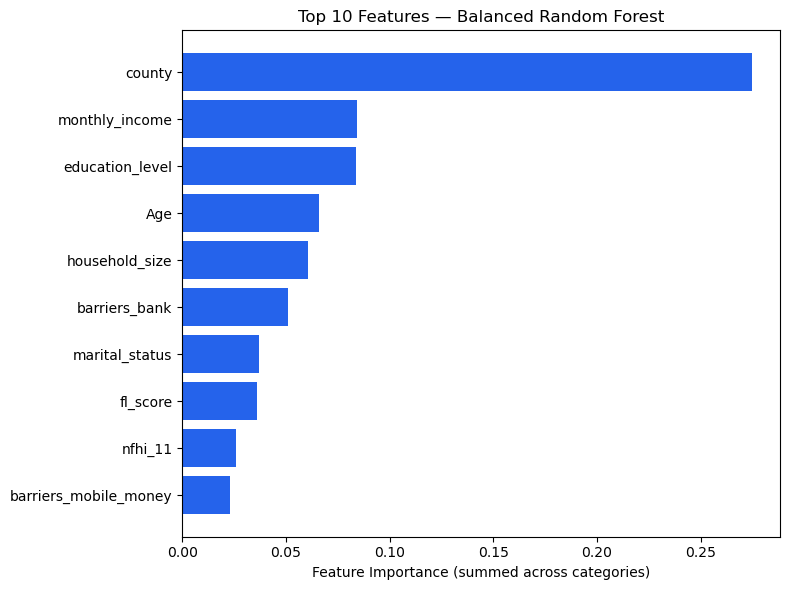

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

feat_names = preprocessor.get_feature_names_out()
importances = random_search.best_estimator_.feature_importances_

# original column groups used when building the preprocessor
one_hot_cols = [
    'location_type','Sex','Age','education_level','marital_status',
    'Savings_formal','Savings_informal','Loan_formal','Loan_informal',
    'defaulted','formal_service_use','mobile_money_access','mobile_ownership_1',
    'experienced_shock','nfhi_11','nfhi_12','nfhi_13','accessto_13k_1month',
    'not_difficult','has_disability','barriers_mobile_money','barriers_bank'
]

def group_name(fname):
    # strip the transformer prefix (e.g. "cat__", "num__", "ord__", "county_te__")
    name = fname.split('__', 1)[1] if '__' in fname else fname

    if fname.startswith('county_te__'):
        return 'county'
    if fname.startswith('num__') or fname.startswith('ord__'):
        return name
    if fname.startswith('cat__'):
        # match against the longest matching original column name
        matches = [c for c in one_hot_cols if name.startswith(c)]
        if matches:
            return max(matches, key=len)
        return name
    return name

groups = pd.Series(importances, index=[group_name(f) for f in feat_names])
grouped_importances = groups.groupby(level=0).sum().sort_values(ascending=False)

top10 = grouped_importances.head(10)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top10.index[::-1], top10.values[::-1], color='#2563eb')
ax.set_xlabel('Feature Importance (summed across categories)')
ax.set_title('Top 10 Features — Balanced Random Forest')
plt.tight_layout()
plt.savefig('feature_importance_grouped.png', dpi=200)
plt.show()

## Data Visualization
Charts, graphs, and plots of the data will be added here.